In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

In [29]:
df= pd.read_csv('cars.csv')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38531 entries, 0 to 38530
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   manufacturer_name  38531 non-null  object 
 1   model_name         38531 non-null  object 
 2   transmission       38531 non-null  object 
 3   color              38531 non-null  object 
 4   odometer_value     38531 non-null  int64  
 5   year_produced      38531 non-null  int64  
 6   engine_fuel        38531 non-null  object 
 7   engine_has_gas     38531 non-null  bool   
 8   engine_type        38531 non-null  object 
 9   engine_capacity    38521 non-null  float64
 10  body_type          38531 non-null  object 
 11  has_warranty       38531 non-null  bool   
 12  state              38531 non-null  object 
 13  drivetrain         38531 non-null  object 
 14  price_usd          38531 non-null  float64
 15  is_exchangeable    38531 non-null  bool   
 16  location_region    385

In [31]:
df.describe()

,odometer_value,year_produced,engine_capacity,price_usd,number_of_photos,up_counter,duration_listed
count,38531.000000,38531.000000,38521.000000,38531.000000,38531.000000,38531.000000,38531.000000
mean,248864.638447,2002.943734,2.055161,6639.971021,9.649062,16.306091,80.577249
std,136072.376530,8.065731,0.671178,6428.152018,6.093217,43.286933,112.826569
min,0.000000,1942.000000,0.200000,1.000000,1.000000,1.000000,0.000000
25%,158000.000000,1998.000000,1.600000,2100.000000,5.000000,2.000000,23.000000
50%,250000.000000,2003.000000,2.000000,4800.000000,8.000000,5.000000,59.000000
75%,325000.000000,2009.000000,2.300000,8990.000000,12.000000,16.000000,91.000000
max,1000000.000000,2019.000000,8.000000,50000.000000,86.000000,1861.000000,2232.000000


In [32]:
df["transmission"].unique()

array(['automatic', 'mechanical'], dtype=object)

## Обработка пропущенных значений


In [33]:
(df.isna().sum()/df.shape[0]*100).sort_values(ascending=False)

engine_capacity      0.025953
manufacturer_name    0.000000
transmission         0.000000
color                0.000000
odometer_value       0.000000
model_name           0.000000
year_produced        0.000000
engine_fuel          0.000000
engine_has_gas       0.000000
engine_type          0.000000
body_type            0.000000
has_warranty         0.000000
state                0.000000
drivetrain           0.000000
price_usd            0.000000
is_exchangeable      0.000000
location_region      0.000000
number_of_photos     0.000000
up_counter           0.000000
feature_0            0.000000
feature_1            0.000000
feature_2            0.000000
feature_3            0.000000
feature_4            0.000000
feature_5            0.000000
feature_6            0.000000
feature_7            0.000000
feature_8            0.000000
feature_9            0.000000
duration_listed      0.000000
dtype: float64

Мы видим что пропущены значения только в "engine_capacity":

-Обработать пропущенные значения в столбце 'engine_capacity' для каждой модели. 

In [34]:
f = lambda x: x.mode().iat[0] if x.notna().any() else np.nan
group_model = df.groupby('model_name')['engine_capacity'].transform(f)
df ['engine_capacity'] = df ['engine_capacity'].fillna(group_model)
df

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,...,True,True,True,False,True,False,True,True,True,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,...,True,False,False,True,True,False,False,False,True,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,...,True,False,False,False,False,False,False,True,True,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,...,False,False,False,False,False,False,False,False,False,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,...,True,False,True,True,False,False,False,False,True,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38526,Chrysler,300,automatic,silver,290000,2000,gasoline,False,gasoline,3.5,...,True,False,False,True,True,False,False,True,True,301
38527,Chrysler,PT Cruiser,mechanical,blue,321000,2004,diesel,False,diesel,2.2,...,True,False,False,True,True,False,False,True,True,317
38528,Chrysler,300,automatic,blue,777957,2000,gasoline,False,gasoline,3.5,...,True,False,False,True,True,False,False,True,True,369
38529,Chrysler,PT Cruiser,mechanical,black,20000,2001,gasoline,False,gasoline,2.0,...,True,False,False,False,False,False,False,False,True,490


In [35]:
(df.isna().sum()/df.shape[0]*100).sort_values(ascending=False)

engine_capacity      0.018167
manufacturer_name    0.000000
transmission         0.000000
color                0.000000
odometer_value       0.000000
model_name           0.000000
year_produced        0.000000
engine_fuel          0.000000
engine_has_gas       0.000000
engine_type          0.000000
body_type            0.000000
has_warranty         0.000000
state                0.000000
drivetrain           0.000000
price_usd            0.000000
is_exchangeable      0.000000
location_region      0.000000
number_of_photos     0.000000
up_counter           0.000000
feature_0            0.000000
feature_1            0.000000
feature_2            0.000000
feature_3            0.000000
feature_4            0.000000
feature_5            0.000000
feature_6            0.000000
feature_7            0.000000
feature_8            0.000000
feature_9            0.000000
duration_listed      0.000000
dtype: float64

Это снизило процент пропусков, но не до 0.
Возможно лучше заполнить из медианой


In [36]:
df ['engine_capacity'] = df ['engine_capacity'].fillna(df ['engine_capacity'].median())

In [37]:
(df.isna().sum()/df.shape[0]*100).sort_values(ascending=False)

manufacturer_name    0.0
model_name           0.0
transmission         0.0
color                0.0
odometer_value       0.0
year_produced        0.0
engine_fuel          0.0
engine_has_gas       0.0
engine_type          0.0
engine_capacity      0.0
body_type            0.0
has_warranty         0.0
state                0.0
drivetrain           0.0
price_usd            0.0
is_exchangeable      0.0
location_region      0.0
number_of_photos     0.0
up_counter           0.0
feature_0            0.0
feature_1            0.0
feature_2            0.0
feature_3            0.0
feature_4            0.0
feature_5            0.0
feature_6            0.0
feature_7            0.0
feature_8            0.0
feature_9            0.0
duration_listed      0.0
dtype: float64


### Заключение
- Недостающие значения обработаны

## Коррекция типов данных
Во всех столбцах типы данных логичны

## Обогащение данных
- "transmission" -> "automatic" + "mechanical"
- "engine_fuel" -> 'fuel_gasoline' + 'fuel_gas' + 'fuel_diesel' + 'fuel_hybrid-petrol' + 'fuel_hybrid-diesel' + 'fuel_electric'
- "engine_type" -> 'type_gasoline' + 'type_diesel' + 'type_electric'
- "state" ->  0: 'emergency'; 0: 'owned'; 2: 'new'
- "drivetrain" -> 'drivetrain_all' + 'drivetrain_front' + 'drivetrain_rear'
- 

In [38]:
df["body_type"].unique()

array(['universal', 'suv', 'sedan', 'hatchback', 'liftback', 'minivan',
       'minibus', 'van', 'pickup', 'coupe', 'cabriolet', 'limousine'],
      dtype=object)

In [39]:
#"transmission" -> "automatic" + "mechanical"
df = pd.get_dummies(df, columns=["transmission"], prefix='trans')

In [40]:
#"engine_fuel" -> 'fuel_gasoline' + 'fuel_gas' + 'fuel_diesel' + 'fuel_hybrid-petrol' + 'fuel_hybrid-diesel' + 'fuel_electric'
df = pd.get_dummies(df, columns=["engine_fuel"], prefix='fuel')

In [41]:
# "engine_type" -> 'type_gasoline' + 'type_diesel' + 'type_electric'
df = pd.get_dummies(df, columns=["engine_type"], prefix='type')

In [42]:
# "drivetrain" -> 'drivetrain_all' + 'drivetrain_front' + 'drivetrain_rear'
df = pd.get_dummies(df, columns=["drivetrain"], prefix='dt')

In [43]:
# "state" ->  0: 'emergency'; 1: 'owned'; 2: 'new'
dict_state = {
    'emergency': 0 ,
    'owned': 1 , 
    'new': 2
}

df["state"] = df["state"].map(dict_state)

In [44]:
df.head(30)

,manufacturer_name,model_name,color,odometer_value,year_produced,engine_has_gas,engine_capacity,body_type,has_warranty,state,...,fuel_gas,fuel_gasoline,fuel_hybrid-diesel,fuel_hybrid-petrol,type_diesel,type_electric,type_gasoline,dt_all,dt_front,dt_rear
0,Subaru,Outback,silver,190000,2010,False,2.5,universal,False,1,...,False,True,False,False,False,False,True,True,False,False
1,Subaru,Outback,blue,290000,2002,False,3.0,universal,False,1,...,False,True,False,False,False,False,True,True,False,False
2,Subaru,Forester,red,402000,2001,False,2.5,suv,False,1,...,False,True,False,False,False,False,True,True,False,False
3,Subaru,Impreza,blue,10000,1999,False,3.0,sedan,False,1,...,False,True,False,False,False,False,True,True,False,False
4,Subaru,Legacy,black,280000,2001,False,2.5,universal,False,1,...,False,True,False,False,False,False,True,True,False,False
5,Subaru,Outback,silver,132449,2011,False,2.5,universal,False,1,...,False,True,False,False,False,False,True,True,False,False
6,Subaru,Forester,black,318280,1998,False,2.5,universal,False,1,...,False,True,False,False,False,False,True,True,False,False
7,Subaru,Legacy,silver,350000,2004,False,2.5,sedan,False,1,...,False,True,False,False,False,False,True,True,False,False
8,Subaru,Outback,grey,179000,2010,False,2.5,universal,False,1,...,False,True,False,False,False,False,True,True,False,False
9,Subaru,Forester,silver,571317,1999,False,2.5,universal,False,1,...,False,True,False,False,False,False,True,True,False,False


In [45]:
df = pd.get_dummies(df, columns=["manufacturer_name"], prefix='manname')
df = pd.get_dummies(df, columns=["model_name"], prefix='modname')

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38531 entries, 0 to 38530
Columns: 1211 entries, color to modname_Таврия
dtypes: bool(1200), float64(2), int64(6), object(3)
memory usage: 47.3+ MB


In [47]:
df.to_csv("cars_proc.csv", index=False)

## EDA

Анализ числовых переменных

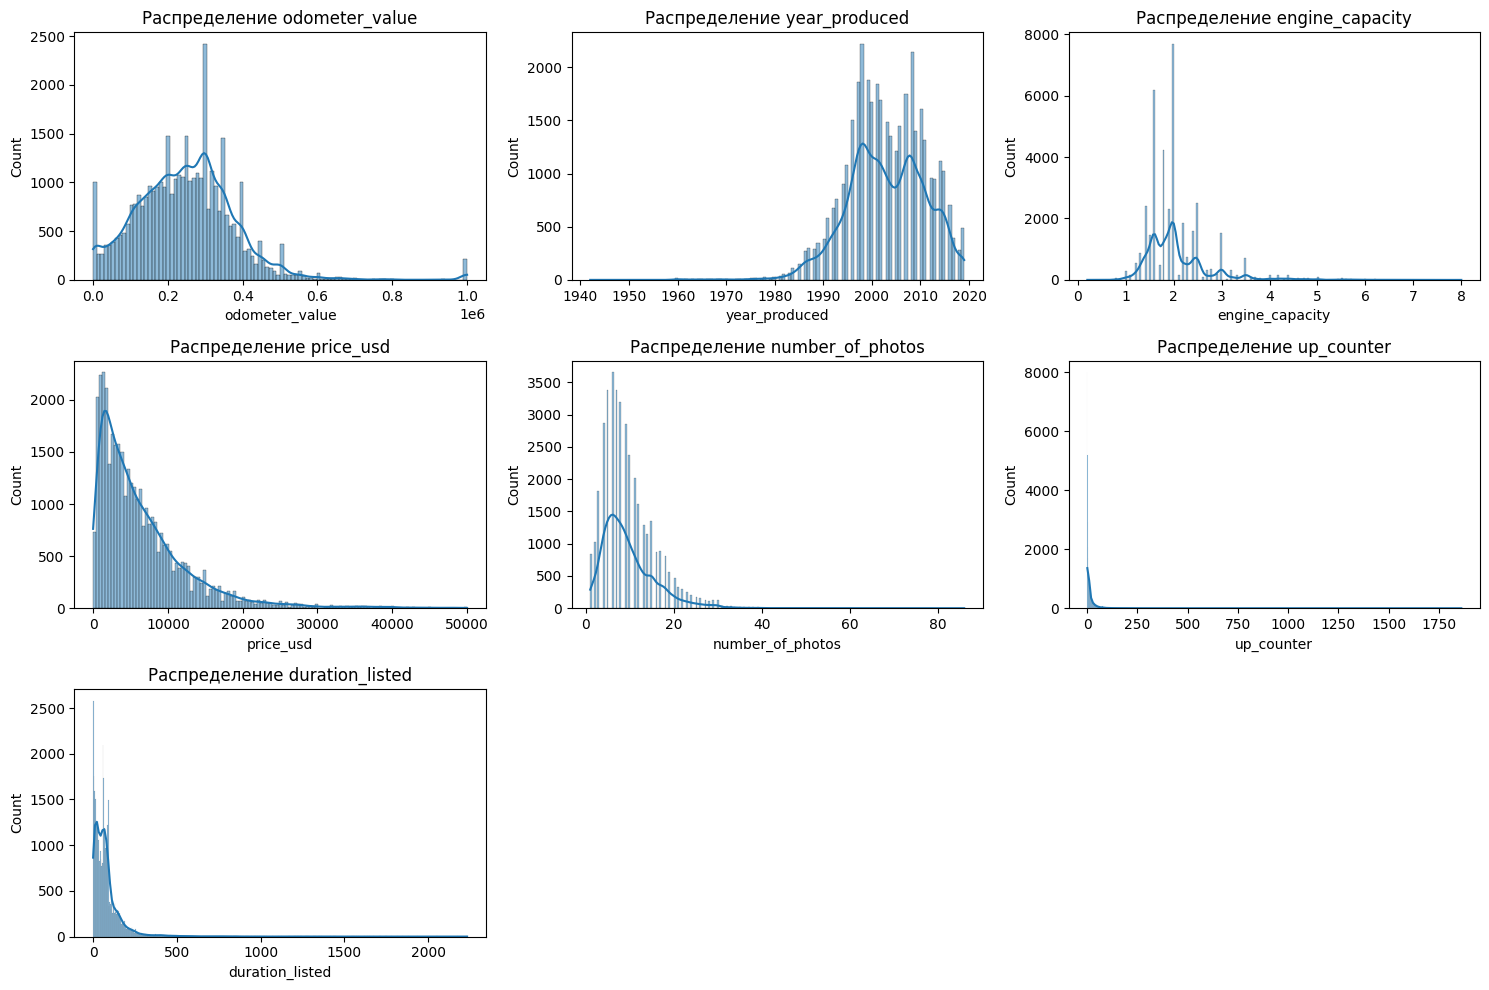

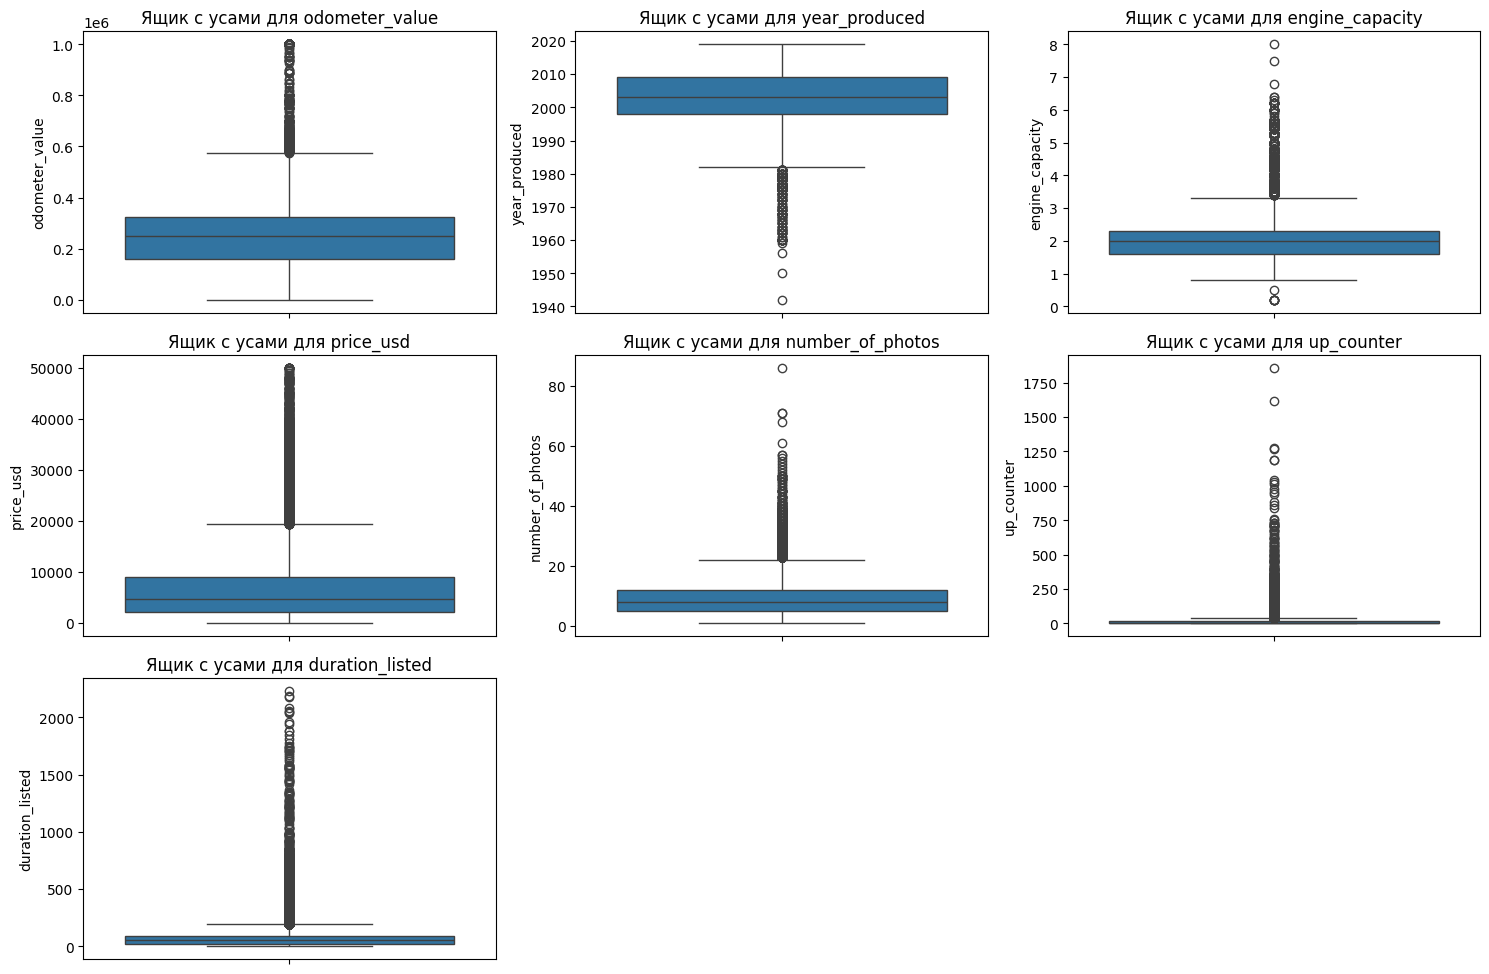

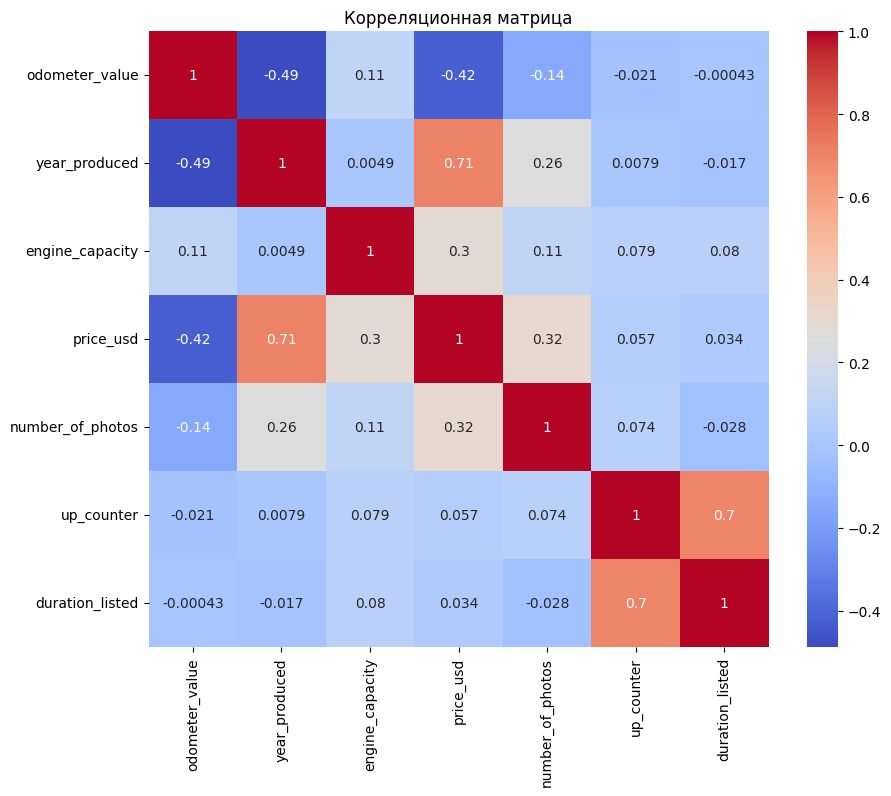

In [48]:
num_cols = ['odometer_value', 'year_produced', 'engine_capacity', 'price_usd', 
            'number_of_photos', 'up_counter', 'duration_listed']

# Графики распределения
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Распределение {col}')
plt.tight_layout()
plt.show()

# Выбросы
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Ящик с усами для {col}')
plt.tight_layout()
plt.show()

# Корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

Анализ категориальных переменных

KeyError: 'manufacturer_name'

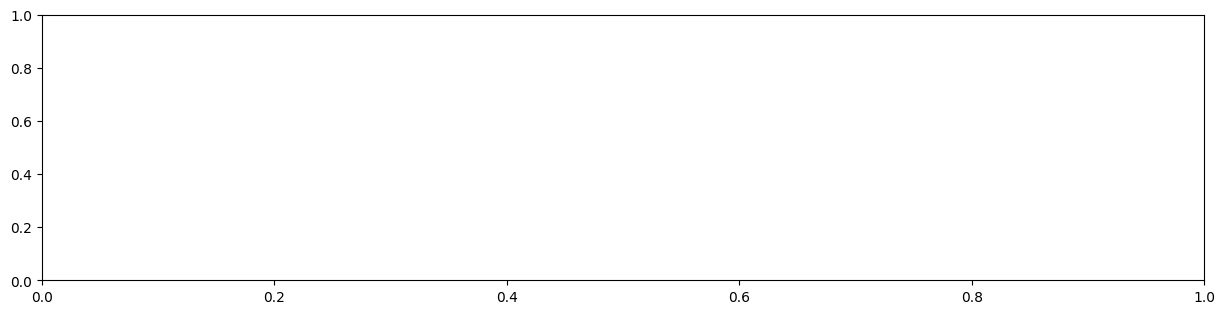

In [49]:
cat_cols = ['manufacturer_name', 'model_name', 'color', 'body_type', 'location_region']

# Топ-20 значений
plt.figure(figsize=(15, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 1, i+1)
    df[col].value_counts().head(20).plot(kind='bar')
    plt.title(f'Топ-20 значений в {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Средняя цена по категориям
for col in cat_cols:
    plt.figure(figsize=(12, 6))
    df.groupby(col)['price_usd'].mean().sort_values(ascending=False).head(20).plot(kind='bar')
    plt.title(f'Средняя цена по {col}')
    plt.ylabel('Средняя цена ($)')
    plt.xticks(rotation=45)
    plt.show()

Анализ булевых переменных


engine_has_gas:
engine_has_gas
False    96.504114
True      3.495886
Name: proportion, dtype: float64

has_warranty:
has_warranty
False    98.834705
True      1.165295
Name: proportion, dtype: float64

is_exchangeable:
is_exchangeable
False    64.740079
True     35.259921
Name: proportion, dtype: float64

feature_0:
feature_0
False    77.145675
True     22.854325
Name: proportion, dtype: float64

feature_1:
feature_1
True     60.71994
False    39.28006
Name: proportion, dtype: float64

feature_2:
feature_2
False    77.618022
True     22.381978
Name: proportion, dtype: float64

feature_3:
feature_3
False    72.41961
True     27.58039
Name: proportion, dtype: float64

feature_4:
feature_4
False    75.853209
True     24.146791
Name: proportion, dtype: float64

feature_5:
feature_5
False    64.392307
True     35.607693
Name: proportion, dtype: float64

feature_6:
feature_6
False    82.902079
True     17.097921
Name: proportion, dtype: float64

feature_7:
feature_7
False    73.626431
True 

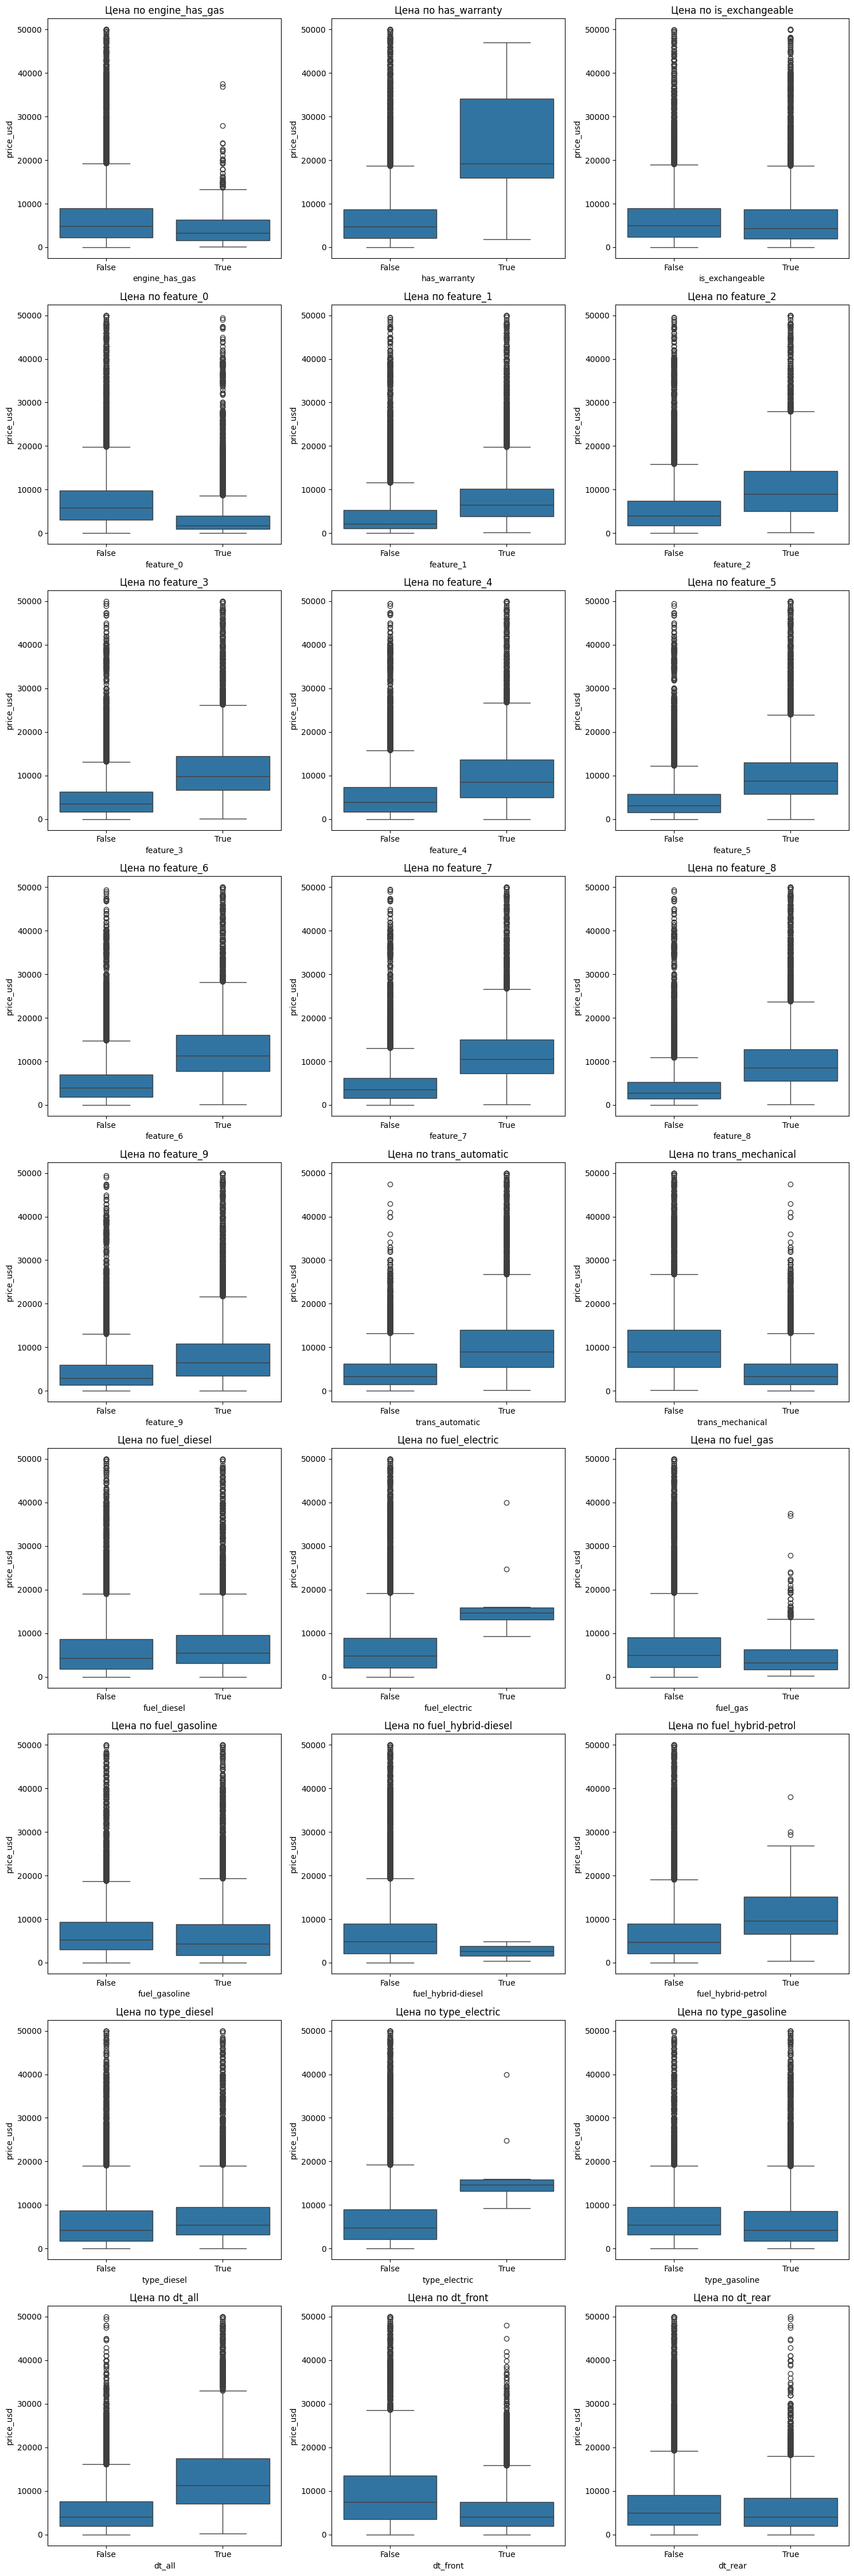

In [ ]:
import math

bool_cols = [col for col in df.columns if df[col].dtype == 'bool']

# Процентное соотношение
for col in bool_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True) * 100)

# Влияние на цену
n_cols = 3  # Желаемое число столбцов
n_rows = math.ceil(len(bool_cols) / n_cols)  # Вычисляем строки

plt.figure(figsize=(15, 5*n_rows))  # Динамический размер по числу строк
for i, col in enumerate(bool_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x=df[col], y=df['price_usd'])
    plt.title(f'Цена по {col}')
plt.tight_layout()
plt.show()

5. Анализ целевой переменной (цена)

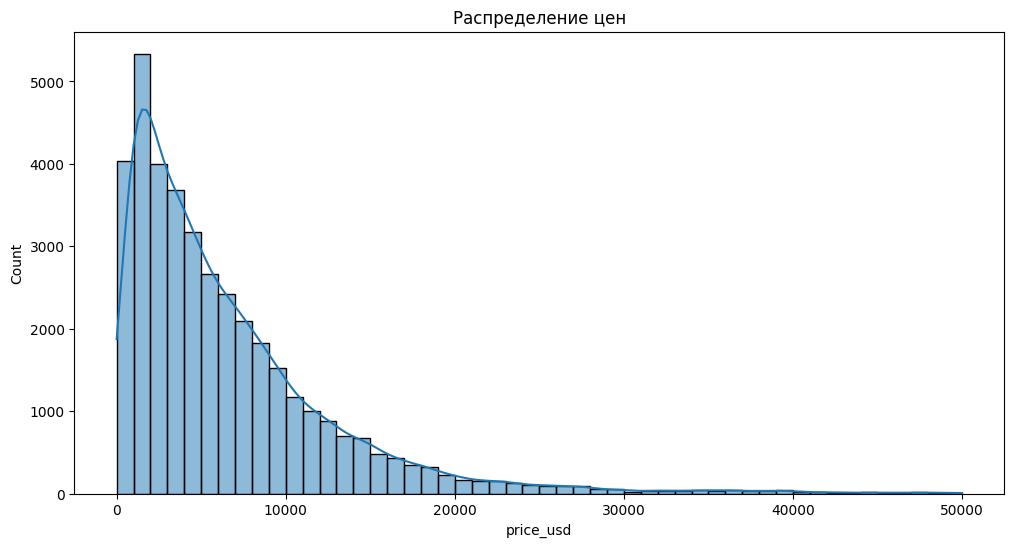

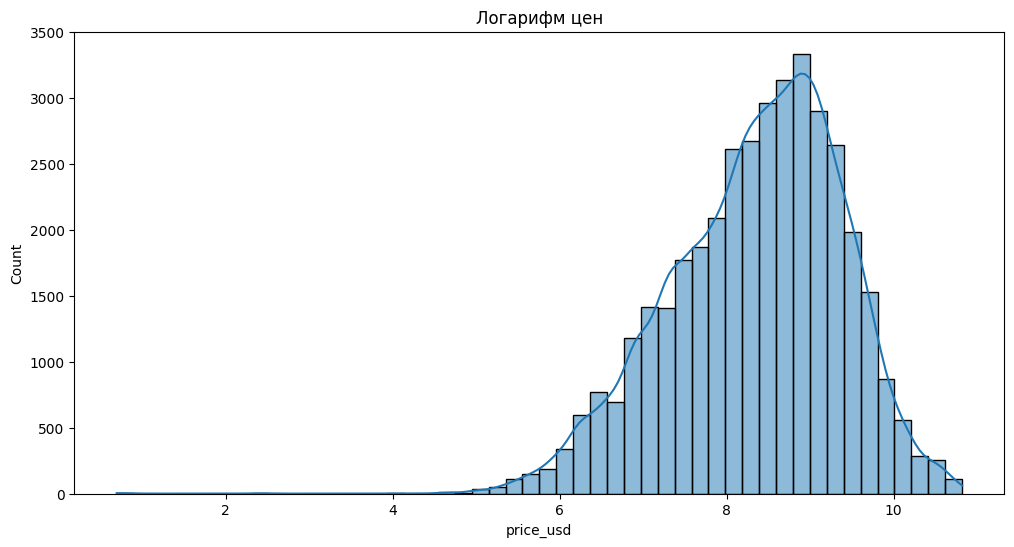

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['price_usd'], kde=True, bins=50)
plt.title('Распределение цен')
plt.show()

# Логарифмирование если нужно
plt.figure(figsize=(12, 6))
sns.histplot(np.log1p(df['price_usd']), kde=True, bins=50)
plt.title('Логарифм цен')
plt.show()

 Анализ временных параметров

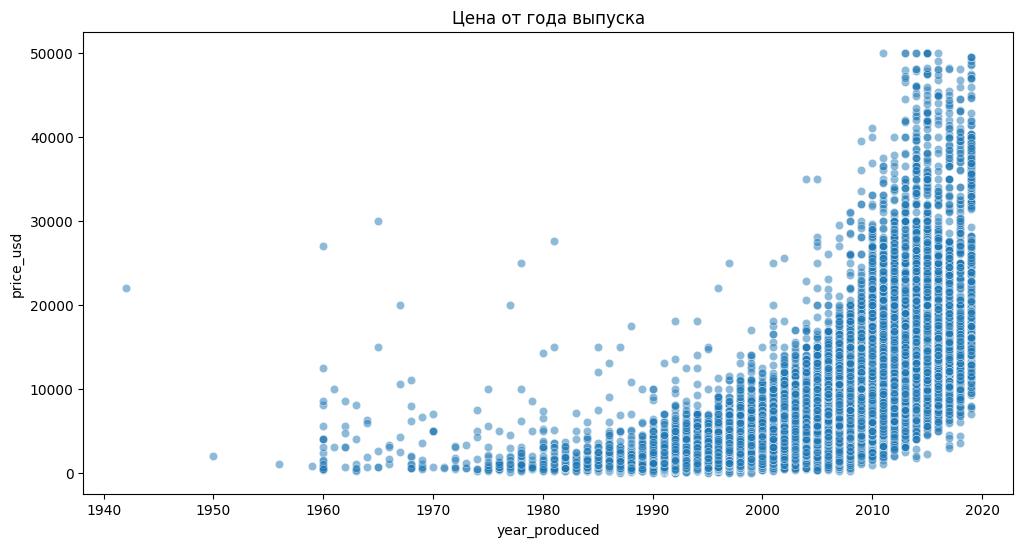

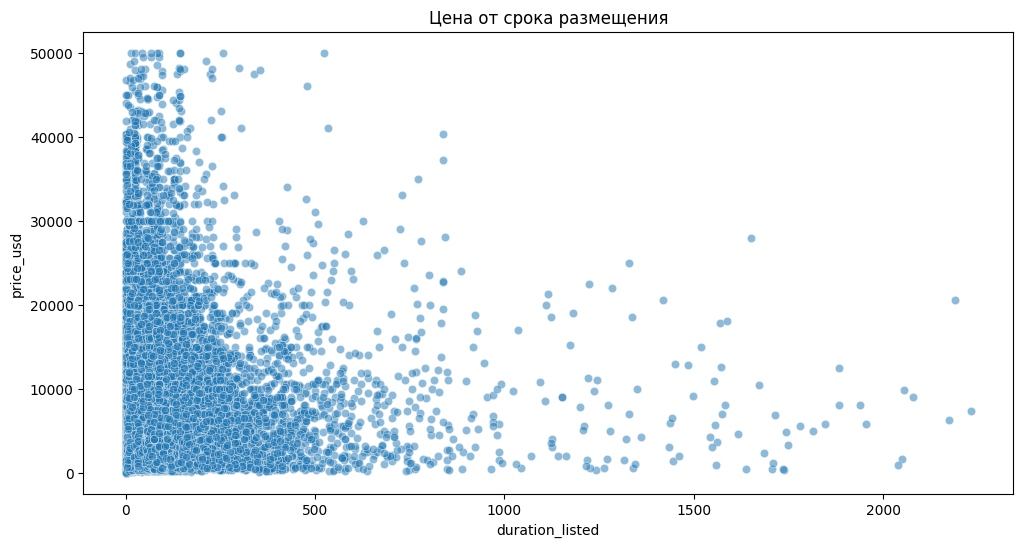

In [ ]:
# Цена vs год выпуска
plt.figure(figsize=(12, 6))
sns.scatterplot(x='year_produced', y='price_usd', data=df, alpha=0.5)
plt.title('Цена от года выпуска')
plt.show()

# Цена vs срок размещения
plt.figure(figsize=(12, 6))
sns.scatterplot(x='duration_listed', y='price_usd', data=df, alpha=0.5)
plt.title('Цена от срока размещения')
plt.show()

Продвинутый анализ

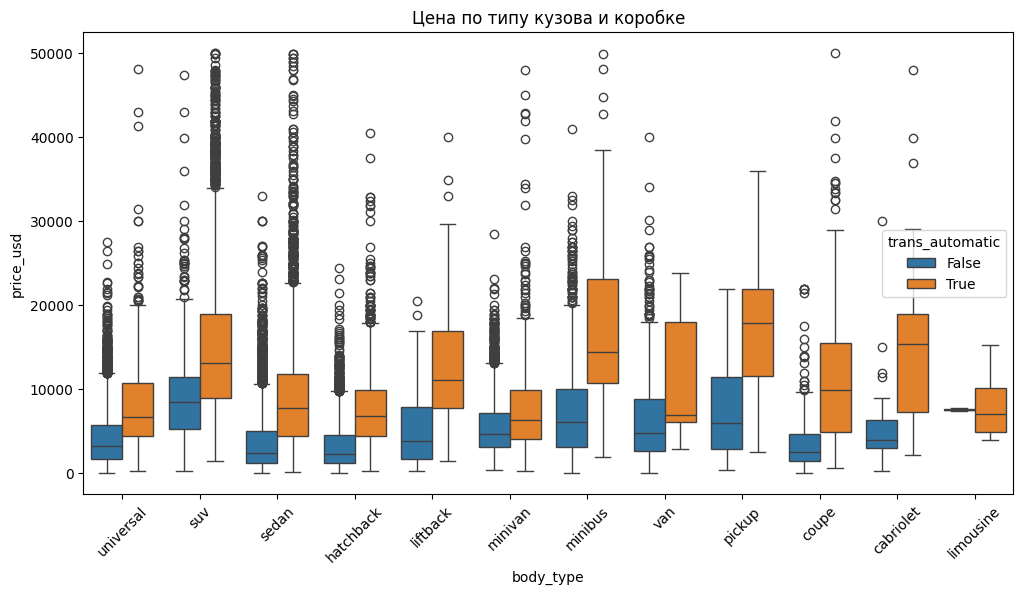

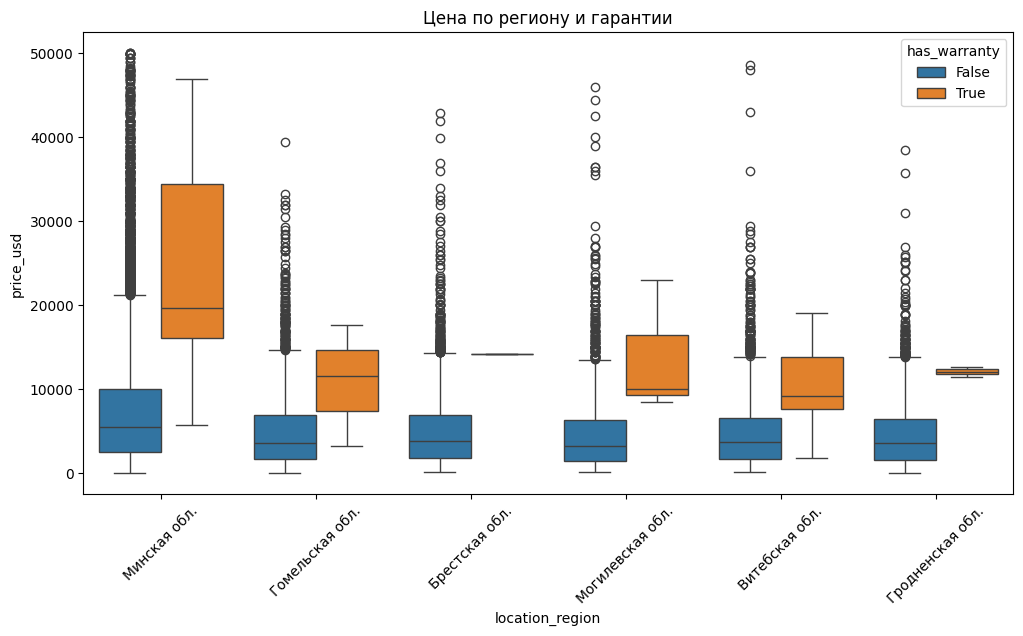

In [ ]:
# Цена по типу кузова и коробке
plt.figure(figsize=(12, 6))
sns.boxplot(x='body_type', y='price_usd', hue='trans_automatic', data=df)
plt.xticks(rotation=45)
plt.title('Цена по типу кузова и коробке')
plt.show()

# Цена по региону и гарантии
plt.figure(figsize=(12, 6))
sns.boxplot(x='location_region', y='price_usd', hue='has_warranty', data=df)
plt.xticks(rotation=45)
plt.title('Цена по региону и гарантии')
plt.show()